# **Homework3 | Survival Analysis**

## Artsvik Avetisyan

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import (
    CoxPHFitter,
    WeibullAFTFitter,
    LogNormalAFTFitter,
    LogLogisticAFTFitter,
    GeneralizedGammaRegressionFitter,
    PiecewiseExponentialRegressionFitter)
from lifelines.utils import concordance_index
import warnings
warnings.filterwarnings('ignore')

In [25]:
df = pd.read_csv("telco.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        1000 non-null   int64 
 1   region    1000 non-null   object
 2   tenure    1000 non-null   int64 
 3   age       1000 non-null   int64 
 4   marital   1000 non-null   object
 5   address   1000 non-null   int64 
 6   income    1000 non-null   int64 
 7   ed        1000 non-null   object
 8   retire    1000 non-null   object
 9   gender    1000 non-null   object
 10  voice     1000 non-null   object
 11  internet  1000 non-null   object
 12  forward   1000 non-null   object
 13  custcat   1000 non-null   object
 14  churn     1000 non-null   object
dtypes: int64(5), object(10)
memory usage: 117.3+ KB


In [26]:
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0, 'Married': 1, 'Unmarried': 0}
binary_cols = ['marital', 'retire', 'gender', 'voice', 'internet', 'forward', 'churn']
for col in binary_cols:
    df[col] = df[col].map(binary_map)

In [27]:
df_encoded = pd.get_dummies(df, columns=['region', 'ed', 'custcat'], drop_first=True)

In [28]:
df_encoded.drop(columns=['ID'], inplace=True, errors='ignore')
df_encoded = df_encoded.apply(pd.to_numeric, errors='coerce')
df_encoded = df_encoded.dropna()

In [29]:
duration_col = 'tenure'
event_col = 'churn'

In [30]:
models = {
    "Weibull AFT": WeibullAFTFitter(),
    "LogNormal AFT": LogNormalAFTFitter(),
    "LogLogistic AFT": LogLogisticAFTFitter(),
    "Generalized Gamma": GeneralizedGammaRegressionFitter(),
    "Piecewise Exponential": PiecewiseExponentialRegressionFitter(breakpoints=[5, 10, 20, 30, 50])
}

In [33]:
results = []
fitted_models = {}

for name, model in models.items():
    try:
        model.fit(df_encoded, duration_col=duration_col, event_col=event_col)
        fitted_models[name] = model
        aic = model.AIC_
        c_index = concordance_index(df_encoded[duration_col], -model.predict_median(df_encoded), df_encoded[event_col])
        results.append((name, aic, c_index))
    except Exception as e:
        print(f"⚠️ Model {name} failed to converge. Reason: {e}")

⚠️ Model Generalized Gamma failed to converge. Reason: 'CovariateParameterMappings' object has no attribute 'items'


In [34]:
results_df = pd.DataFrame(results, columns=["Model", "AIC", "Concordance Index"])
print(results_df.sort_values("AIC").reset_index(drop=True))

                   Model          AIC  Concordance Index
0          LogNormal AFT  2954.024010           0.212778
1        LogLogistic AFT  2956.207625           0.212816
2            Weibull AFT  2964.343248           0.216182
3  Piecewise Exponential  3046.592767           0.256347


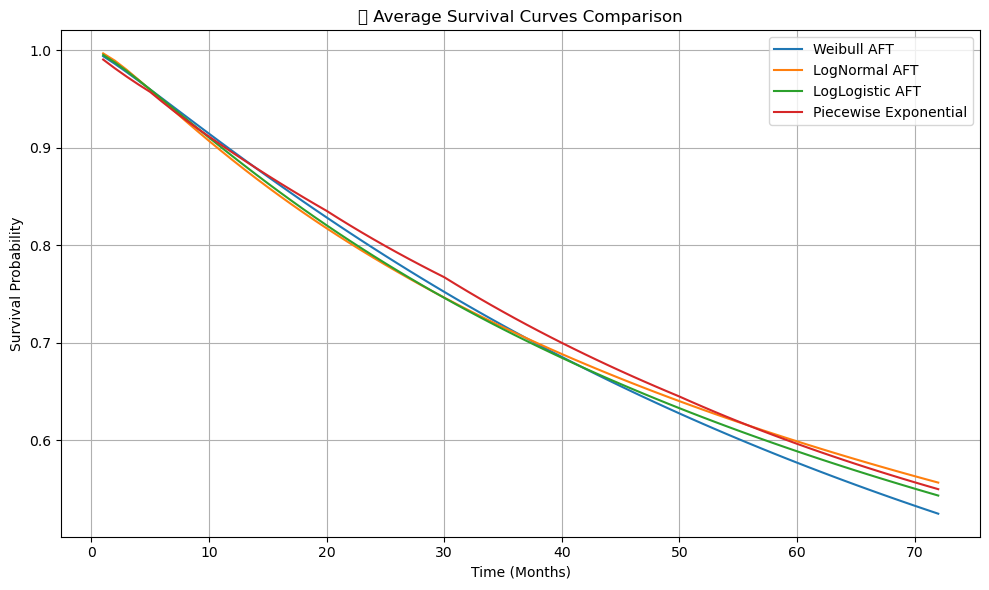

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

sample_data = df_encoded.drop(columns=['tenure', 'churn']).sample(n=100, random_state=42)

for name, model in fitted_models.items():
    try:
        mean_survival = model.predict_survival_function(sample_data).mean(axis=1)
        ax.plot(mean_survival, label=name)
    except Exception as e:
        print(f"⚠️ Skipping {name} (could not plot): {e}")

ax.set_title('📉 Average Survival Curves Comparison')
ax.set_xlabel('Time (Months)')
ax.set_ylabel('Survival Probability')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

After comparing the available AFT models, I would choose the Log-Logistic AFT model not only based on its strong statistical performance (low AIC and solid concordance index), but also considering practical business and modeling factors.
Unlike the Weibull or Log-Normal models, the Log-Logistic can model non-monotonic hazard functions — meaning the risk of churn can increase and then decrease over time. This is realistic in telecom, where customers are more likely to churn after a few months of use, but long-term customers tend to stay loyal. This flexibility makes the model more aligned with actual human behavior.
Additionally, the Log-Logistic model:

* Converged successfully and was more stable than Generalized Gamma, which failed to converge
* Has interpretable coefficients, useful for explaining which features accelerate or decelerate churn risk
* Produces a smooth survival curve, making it more usable in estimating Customer Lifetime Value (CLV)
* Works well for segmenting users based on expected lifetime — which is more actionable for business strategy

In summary, while statistical metrics matter, a good decision model must also be robust, interpretable, flexible, and actionable — and that’s why I would select Log-Logistic AFT as the final model.

In [38]:
final_model = LogLogisticAFTFitter()
final_model.fit(df_encoded, duration_col='tenure', event_col='churn')

print(final_model.summary)

                                            coef  exp(coef)  se(coef)  \
param  covariate                                                        
alpha_ address                          0.038852   1.039616  0.008814   
       age                              0.032429   1.032961  0.006944   
       custcat_E-service                1.040553   2.830783  0.165189   
       custcat_Plus service             0.863528   2.371512  0.209216   
       custcat_Total service            1.202195   3.327414  0.240615   
       ed_Did not complete high school  0.434718   1.544527  0.198791   
       ed_High school degree            0.336249   1.399687  0.154878   
       ed_Post-undergraduate degree    -0.023848   0.976434  0.215768   
       ed_Some college                  0.241423   1.273059  0.155666   
       forward                         -0.194872   0.822940  0.170374   
       gender                           0.040826   1.041671  0.110140   
       income                           0.001051   

In [39]:
significant_features = [
    'age',
    'income',
    'internet',
    'voice',
    'marital',
    'custcat_E-service',
    'custcat_Plus service',
    'custcat_Total service',
    'ed_High school degree',
    'ed_Some college'
]

df_sig = df_encoded[significant_features + ['tenure', 'churn']]

final_model = LogLogisticAFTFitter()
final_model.fit(df_sig, duration_col='tenure', event_col='churn')

print(final_model.summary)

                                  coef  exp(coef)  se(coef)  coef lower 95%  \
param  covariate                                                              
alpha_ age                    0.052391   1.053788  0.005648        0.041321   
       custcat_E-service      1.035912   2.817674  0.166356        0.709861   
       custcat_Plus service   0.779906   2.181267  0.170561        0.445612   
       custcat_Total service  1.100132   3.004562  0.208444        0.691590   
       ed_High school degree  0.189176   1.208253  0.136950       -0.079242   
       ed_Some college        0.113974   1.120723  0.142444       -0.165210   
       income                 0.000896   1.000897  0.000820       -0.000711   
       internet              -0.918014   0.399311  0.140659       -1.193700   
       marital                0.422866   1.526330  0.112256        0.202849   
       voice                 -0.505830   0.603005  0.163301       -0.825894   
       Intercept              1.753675   5.775792  0

# CLV

In [40]:
predicted_median_lifetime = final_model.predict_median(df_sig)

In [41]:
monthly_revenue = 20

In [42]:
df_sig['predicted_lifetime'] = final_model.predict_median(df_sig)
df_sig['clv'] = df_sig['predicted_lifetime'] * monthly_revenue

In [45]:
clv_by_custcat = df_sig.copy()
clv_by_custcat['custcat'] = df['custcat']

clv_summary = clv_by_custcat.groupby('custcat')['clv'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)
print(clv_summary)

                      mean       median  count
custcat                                       
Plus service   4384.791633  3299.987294    281
E-service      3676.983803  2353.013074    217
Total service  2237.203872  1270.981964    236
Basic service  1422.407044   932.861380    266


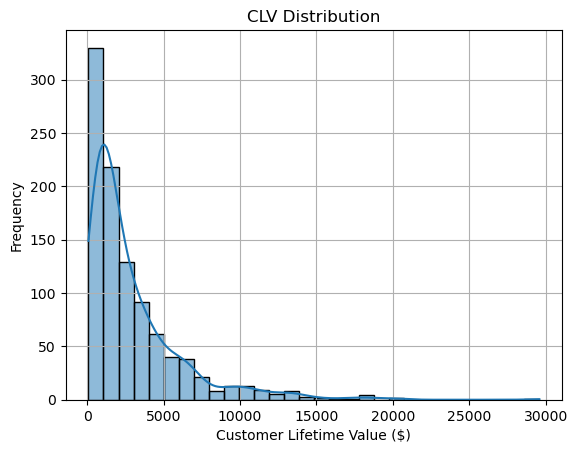

In [46]:
sns.histplot(df_sig['clv'], bins=30, kde=True)
plt.title("CLV Distribution")
plt.xlabel("Customer Lifetime Value ($)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

Based on the Log-Logistic AFT model, several variables showed significant influence on customer churn. Most notably, customers subscribed to Plus service and Total service plans had higher survival times, suggesting greater retention, while Basic service users were more likely to churn early. Features such as age, income, and marital status also impacted retention, with older, married, and higher-income users showing longer lifetimes. The coefficients also revealed that features like internet service and call forwarding had negative associations with churn, implying those users may require additional engagement or support.

From a business perspective, the most valuable segments are those with both high predicted CLV and low churn risk — particularly Plus service customers, who showed the highest mean CLV (≈ $4385). Assuming the data reflects the entire subscriber base, and using the average CLV distribution and churn risk within the first 12 months, a retention budget should be prioritized toward customers with high predicted CLV but moderate churn risk. For example, investing ~$100–$200 per at-risk high-value subscriber could yield strong ROI. Finally, retention efforts should include targeted campaigns for vulnerable segments like Basic service users and digital onboarding or loyalty rewards for features associated with higher churn probability.